In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# %matplotlib inline

In [2]:
# read files
df_contacts = pd.read_csv("data/contacts-raw.csv")

df_companies = pd.read_csv("data/companies-raw.csv")

In [3]:
df_companies.columns = df_companies.columns.str.replace(' ','_').str.lower()
df_contacts.columns = df_contacts.columns.str.replace(' ','_').str.lower()

In [4]:
df_contacts.record_id.nunique()

5000

In [5]:
df_contacts.info()
# df_contacts.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   record_id                     5279 non-null   object
 1   email                         5279 non-null   object
 2   create_date                   5279 non-null   object
 3   custom_source                 5279 non-null   object
 4   self_reported_source          4295 non-null   object
 5   first_demo_booked_date        3584 non-null   object
 6   first_free_trial_signup_date  4215 non-null   object
dtypes: object(7)
memory usage: 288.8+ KB


In [18]:
# df_contacts.info()
# df_companies.info()

In [19]:
# check for duplicates
df_contacts[ df_contacts.duplicated()].shape

(0, 7)

In [20]:
# dedupe contacts
df_contacts = df_contacts.drop_duplicates().copy()

In [21]:
df_contacts.info()
# df_contacts.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   record_id                     5000 non-null   object        
 1   email                         5000 non-null   object        
 2   create_date                   5000 non-null   object        
 3   custom_source                 5000 non-null   object        
 4   self_reported_source          4073 non-null   object        
 5   first_demo_booked_date        3407 non-null   datetime64[ns]
 6   first_free_trial_signup_date  3997 non-null   datetime64[ns]
dtypes: datetime64[ns](2), object(5)
memory usage: 312.5+ KB


In [22]:
# df_contacts.columns
contact_date_columns = ['first_demo_booked_date', 'first_free_trial_signup_date']

In [23]:
df_contacts[contact_date_columns] = df_contacts[contact_date_columns].apply(pd.to_datetime)

In [24]:
# df_contacts.custom_source.value_counts(dropna = False)
# df_contacts.record_id.duplicated().sum()

In [25]:
df_companies.info()
# df_companies.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3266 entries, 0 to 3265
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   company_domain              3266 non-null   object
 1   record_id                   3266 non-null   object
 2   industry                    3266 non-null   object
 3   number_of_employees         3266 non-null   object
 4   region                      3266 non-null   object
 5   create_date                 3266 non-null   object
 6   became_a_lead_date          3266 non-null   object
 7   became_a_sql_date           1436 non-null   object
 8   became_an_opportunity_date  765 non-null    object
 9   became_a_customer_date      394 non-null    object
 10  churn_date                  95 non-null     object
dtypes: object(11)
memory usage: 280.8+ KB


In [26]:
co_date_cols = df_companies.columns[df_companies.columns.str.contains('became')]

In [27]:
co_date_cols = co_date_cols.append(pd.Index(["churn_date", "create_date"]))

In [28]:
df_companies[co_date_cols] = df_companies[co_date_cols].apply(pd.to_datetime)
# df_companies[co_date_cols]

In [29]:
# employee numbers -> ordered categorical 
df_companies.number_of_employees = pd.Categorical(df_companies.number_of_employees).reorder_categories(['1-10', '11-30', '31-50', '51-100', '100+'], ordered = True)

In [30]:
df_companies.create_date.equals(df_companies.became_a_lead_date)


True

In [31]:
df_companies.number_of_employees.value_counts(dropna = False).sort_index()
# df_companies.info()

number_of_employees
1-10      659
11-30     689
31-50     637
51-100    619
100+      662
Name: count, dtype: int64

In [32]:
# attempting join on record_id - failed, fair enough
pd.merge(df_companies, df_contacts, on = 'record_id', indicator = True)

,company_domain,record_id,industry,number_of_employees,region,create_date_x,became_a_lead_date,became_a_sql_date,became_an_opportunity_date,became_a_customer_date,churn_date,email,create_date_y,custom_source,self_reported_source,first_demo_booked_date,first_free_trial_signup_date,_merge


In [33]:
# df_companies.info()
df_companies.query('number_of_employees >= "51-100" and create_date >= "2020-01-01" and create_date < "2024-01-01"').describe()

,create_date,became_a_lead_date,became_a_sql_date,became_an_opportunity_date,became_a_customer_date,churn_date
count,1281,1281,582,297,157,45
mean,2021-10-19 06:02:17.242779136,2021-10-19 06:02:17.242779136,2021-12-02 02:15:41.463917824,2022-01-10 14:37:04.097643264,2022-02-15 07:12:17.700636928,2023-03-09 10:47:17.111110912
min,2020-01-01 02:26:26,2020-01-01 02:26:26,2020-01-12 13:32:33,2020-01-24 13:32:33,2020-04-07 19:19:14,2021-02-03 08:19:24
25%,2020-10-13 08:27:43,2020-10-13 08:27:43,2020-11-18 05:04:03,2021-01-01 23:19:37,2021-03-11 05:15:53,2022-04-21 15:56:14
50%,2021-08-23 11:00:21,2021-08-23 11:00:21,2021-09-18 08:57:56.500000,2021-11-04 10:29:41,2021-11-28 00:14:55,2023-03-21 18:11:26
75%,2022-10-30 05:33:42,2022-10-30 05:33:42,2022-12-14 11:53:35.750000128,2023-01-03 10:06:10,2023-02-14 07:55:47,2023-12-31 21:37:13
max,2023-12-29 18:53:17,2023-12-29 18:53:17,2024-03-15 18:31:09,2024-06-11 20:49:37,2024-09-05 20:49:37,2025-06-15 17:28:42


In [34]:
# attempting merge on doman - email domain
df_contacts[['email_name','email_domain' ]] = df_contacts.email.str.split("@", expand = True)

In [35]:
# attempting join on domain - all good
df_merged = pd.merge(
    df_companies, 
    df_contacts, 
    left_on = 'company_domain', 
    right_on ='email_domain', 
    indicator = True, 
    validate = "1:m"
)

In [36]:
df_merged._merge.value_counts()

_merge
both          5000
left_only        0
right_only       0
Name: count, dtype: int64

In [37]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   company_domain                5000 non-null   object        
 1   record_id_x                   5000 non-null   object        
 2   industry                      5000 non-null   object        
 3   number_of_employees           5000 non-null   category      
 4   region                        5000 non-null   object        
 5   create_date_x                 5000 non-null   datetime64[ns]
 6   became_a_lead_date            5000 non-null   datetime64[ns]
 7   became_a_sql_date             2272 non-null   datetime64[ns]
 8   became_an_opportunity_date    1260 non-null   datetime64[ns]
 9   became_a_customer_date        618 non-null    datetime64[ns]
 10  churn_date                    129 non-null    datetime64[ns]
 11  record_id_y                   

#### The cusotmer company tests a mixed approach offering a CTA for starting a free-trial and a CTA for booking a demo. Answer the following:

#### Is a prospect company more likely to convert from lead to customer if they first have a free-trial or if they first have a demo?

In [40]:
# # checks
# df_merged.company_domain.nunique() == df_merged.record_id_x.nunique()
# df_merged.groupby(['company_domain','record_id_x']).ngroups

In [41]:
company_first_event = (
df_merged.groupby(['company_domain', 'record_id_x'])
                    .agg({
                        'first_demo_booked_date': 'min',
                        'first_free_trial_signup_date': 'min',
                        'record_id_y': 'count',
                        'became_a_customer_date': lambda col: col.notna().any(),
                    })
)

In [42]:
# company_first_event.head()

In [43]:
company_first_event.became_a_customer_date.value_counts()
# describe(include='all')
# company_first_event.query('first_demo_booked_date.isnull() and first_free_trial_signup_date.isnull()')

became_a_customer_date
False    2872
True      394
Name: count, dtype: int64

In [44]:
company_first_event.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3266 entries, ('abbott.info', '5a8c8ff9-8f90-4455-8bf1-494f90c87ec9') to ('zuniga.org', '8925b1b5-eb3d-4db4-84eb-3a16b2e96d40')
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   first_demo_booked_date        2399 non-null   datetime64[ns]
 1   first_free_trial_signup_date  2702 non-null   datetime64[ns]
 2   record_id_y                   3266 non-null   int64         
 3   became_a_customer_date        3266 non-null   bool          
dtypes: bool(1), datetime64[ns](2), int64(1)
memory usage: 143.6+ KB


In [48]:
# impute NaT with future date for further porcessing
company_first_event[['first_free_trial_signup_date', 'first_demo_booked_date']] = company_first_event[['first_free_trial_signup_date', 'first_demo_booked_date']]\
            .fillna(pd.to_datetime('2030-01-01'))

In [49]:
company_first_event['co_first_event'] = \
(
    company_first_event.first_demo_booked_date > company_first_event.first_free_trial_signup_date 
).replace({ True: 'trial', False: 'demo' })

In [50]:
company_first_event.co_first_event.value_counts(dropna = False) #/ company_first_event.shape[0]

co_first_event
demo     1701
trial    1565
Name: count, dtype: int64

P(C|t) = Count of Companies( trial first AND Customer ) / Count of Companies (trial first)   
P(C|d) = Count of Companies( demo first AND Customer ) / Count of Companies (demo first)

In [57]:
print(p_trial_first := company_first_event.query('co_first_event == "trial" & became_a_customer_date').shape[0] / company_first_event.query('co_first_event == "trial"').shape[0]
)

0.131629392971246


In [56]:
print(p_demo_first := company_first_event.query('co_first_event == "demo" & became_a_customer_date').shape[0] / company_first_event.query('co_first_event == "demo"').shape[0])

0.11052322163433274


In [58]:
p_trial_first / p_demo_first

1.1909659438515396

The diff is only 2 percentaghe points or 19%. Is this significant statistically speaking?

#### Using seaborne plotting with confidence interval boorstrapping

In [59]:
# company_first_event.columns
# company_first_event.shape
# company_first_event.isnull().sum()
# company_first_event.info()
# company_first_event.query('became_a_customer_date')

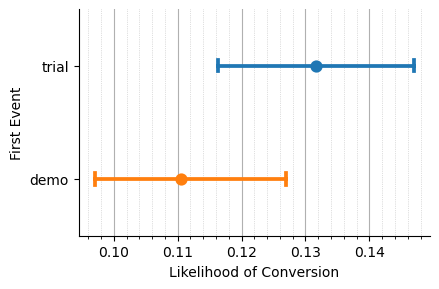

In [63]:
# plot winrates with .95 confidence intervals
# sns.set_style("whitegrid")

g = sns.catplot(
    data= company_first_event, 
    y='co_first_event',
    hue = 'co_first_event',
    x='became_a_customer_date', 
    kind='point',
    errorbar=('ci', 95), # Configures the 95% confidence interval
    capsize=.1,
    linestyle='none',
    height = 3, 
    aspect = 1.5, 
)

# Customizing labels
g.set_axis_labels("Likelihood of Conversion", "First Event")
# plt.title("Conditional Likelihood of Becoming a Customer")
# plt.show()

minor_step = 0.002
for ax in g.axes.flat:
    # Set the locator for the x-axis
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(minor_step))
    # Customize the appearance of the minor grid
    ax.grid(which='minor', axis='x', linestyle=':', linewidth='0.5', color='gray', alpha=0.5)
    ax.grid(which='major', axis='x', linestyle='-', linewidth='0.8')

The plot shows that companies starting with a trial generally have a higher likelihood of conversion than those starting with a demo, but the slight overlap in confidence intervals (CIs) adds a layer of nuance to the statistical significance.  
the point estimate for "trial" (~0.132) is well outside the "demo" interval, and vice versa. This suggests that while there is some uncertainty, there is a strong probability that the trial group truly converts at a higher rate. 

Business considerations. We are looking at a difference between ~11% and ~13%. You should ask yourself if a $2\%$ lift in conversion is "meaningful" enough for the business to prioritize trials over demos, regardless of the $p$-value.

#### Chi-squared test

In [79]:
from scipy.stats import chi2_contingency

# 1. Create a contingency table (cross-tabulation)
# This counts how many trials/demos became customers vs. did not
contingency_table = pd.crosstab(
    company_first_event['co_first_event'], 
    company_first_event['became_a_customer_date']
)

print("Contingency Table:")
print(contingency_table)
print("-" * 30)

# 2. Perform the Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

Contingency Table:
became_a_customer_date  False  True 
co_first_event                      
demo                     1513    188
trial                    1359    206
------------------------------
Chi-squared Statistic: 3.2267
P-value: 0.0724
Degrees of Freedom: 1


 The Statistical Verdict: In most scientific and business contexts, a threshold (alpha) of 0.05 is used to determine significance. Your Result ($p = 0.0724$): Since $0.0724 > 0.05$, we fail to reject the null hypothesis.  
 In Plain English: We cannot say with $95\%$ certainty that the "Trial" group converts better than the "Demo" group. There is a 7.24% chance that the $2.1\%$ difference you observed is just "noise" or random luck.

Despite the lack of a "slam dunk" statistical result, the data still tells a compelling story:  
Trial Conversion: $13.16\%$ ($206 / 1565$)  
Demo Conversion: $11.05\%$ ($188 / 1701$)  
The Lift: The Trial group is converting roughly 19% better than the Demo group in relative terms.

#### Check it with Bayes : P(C|t) = P(t|C) * P(C) / P(t)   P(C|d) = P(d|C) * P(C) / P(d)

In [56]:
customer_first_event = company_first_event.query('became_a_customer_date')

In [57]:
# P(C)
P_Customer = customer_first_event.shape[0] / company_first_event.shape[0]

In [58]:
# P(d)
P_demo = company_first_event.query('co_first_event == "demo"').shape[0] / company_first_event.shape[0]

In [59]:
# P(t)
P_trial = company_first_event.query('co_first_event == "trial"').shape[0] / company_first_event.shape[0]

In [60]:
tmp_s = customer_first_event.co_first_event.value_counts() / customer_first_event.shape[0]

In [80]:
tmp_s.demo * P_Customer / P_demo

np.float64(0.11052322163433274)

In [81]:
tmp_s.trial * P_Customer / P_trial

np.float64(0.131629392971246)